<a href="https://colab.research.google.com/github/Lasp10/EmnistEval/blob/main/emnisteval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import os
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv('/content/emnist-letters-train.csv')
df2 = pd.read_csv('/content/emnist-letters-test.csv')
print(df2.head())
train_images = df.drop('23', axis = 1)
train_images = train_images/255

train_labels = df['23']

test_images = df2.drop('1', axis = 1)
test_labels = df2['1']

test_images /= 255
train_images = np.array(train_images)
test_images = np.array(test_images)
train_images = train_images.reshape((88799, 28, 28, 1))
test_images = test_images.reshape((14799, 28, 28, 1))
print(test_images.shape)




   1  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.548  0.549  0.550  \
0  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.551  0.552  0.553  0.554  0.555  0.556  0.557  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(14799, 28, 28, 1)


In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = (28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation = 'relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(27, activation = 'softmax'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 13, 13, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 1600)              0         
                                                                 
 dense_1 (Dense)             (None, 27)               

In [ ]:
model.compile(optimizer = "adam", loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits =True), metrics = ['accuracy'])


In [ ]:
epochs = 10
history = model.fit(train_images, train_labels, epochs = epochs, validation_split = 0.2)
model.save('emnist_cnn.h5')


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5727: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


2220/2220 [==============================] - 13s 4ms/step - loss: 0.5720 - accuracy: 0.8248 - val_loss: 0.3666 - val_accuracy: 0.8875
Epoch 2/10
2220/2220 [==============================] - 9s 4ms/step - loss: 0.3074 - accuracy: 0.9010 - val_loss: 0.2987 - val_accuracy: 0.9057
Epoch 3/10
2220/2220 [==============================] - 9s 4ms/step - loss: 0.2462 - accuracy: 0.9189 - val_loss: 0.2831 - val_accuracy: 0.9080
Epoch 4/10
2220/2220 [==============================] - 8s 4ms/step - loss: 0.2102 - accuracy: 0.9285 - val_loss: 0.2590 - val_accuracy: 0.9218
Epoch 5/10
2220/2220 [==============================] - 9s 4ms/step - loss: 0.1837 - accuracy: 0.9367 - val_loss: 0.2467 - val_accuracy: 0.9257
Epoch 6/10
2220/2220 [==============================] - 10s 5ms/step - loss: 0.1628 - accuracy: 0.9429 - val_loss: 0.2492 - val_accuracy: 0.9212
Epoch 7/10
2220/2220 [==============================] - 9s 4ms/step - loss: 0.1466 - accuracy: 0.9474 - val_loss: 0.2534 - val_accuracy: 0.9239
E

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


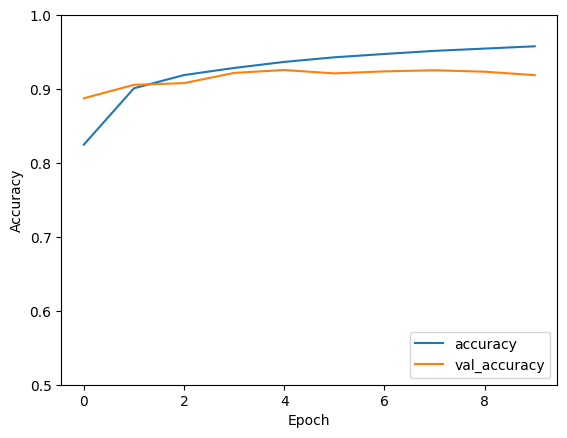

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose = 2)

463/463 - 1s - loss: 0.3224 - accuracy: 0.9056 - 999ms/epoch - 2ms/step


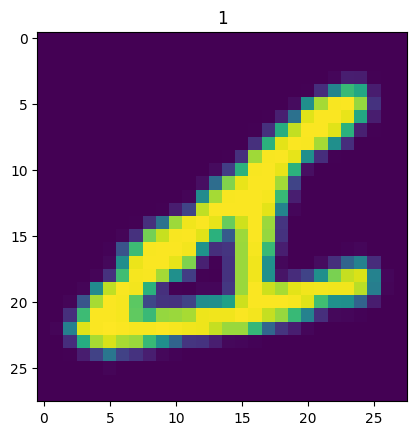

In [ ]:
plt.imshow(test_images[0])
plt.title(test_labels[0])
plt.show()

In [ ]:
img = test_images[0]
img = np.expand_dims(img,0)

In [ ]:
y_predict = model.predict(img)
print(y_predict)

1/1 [==============================] - 0s 191ms/step
[[1.9839093e-12 9.9994421e-01 1.5837428e-07 1.2289287e-17 4.8150339e-10
  1.2658201e-13 6.4852712e-10 9.7767279e-06 1.3504556e-06 4.0007177e-12
  3.5100707e-14 1.8837218e-10 1.4670442e-06 1.7991430e-11 7.4688536e-08
  5.2808073e-08 1.2181928e-07 4.2428575e-05 3.5264034e-07 2.3418659e-11
  6.3584636e-14 1.7797467e-11 1.7984805e-15 5.8339005e-13 1.8336950e-10
  2.4039704e-09 4.5063774e-17]]


In [ ]:
np.argmax(y_predict)


1

In [ ]:
import string
class_names = string.ascii_lowercase
class_names


'abcdefghijklmnopqrstuvwxyz'

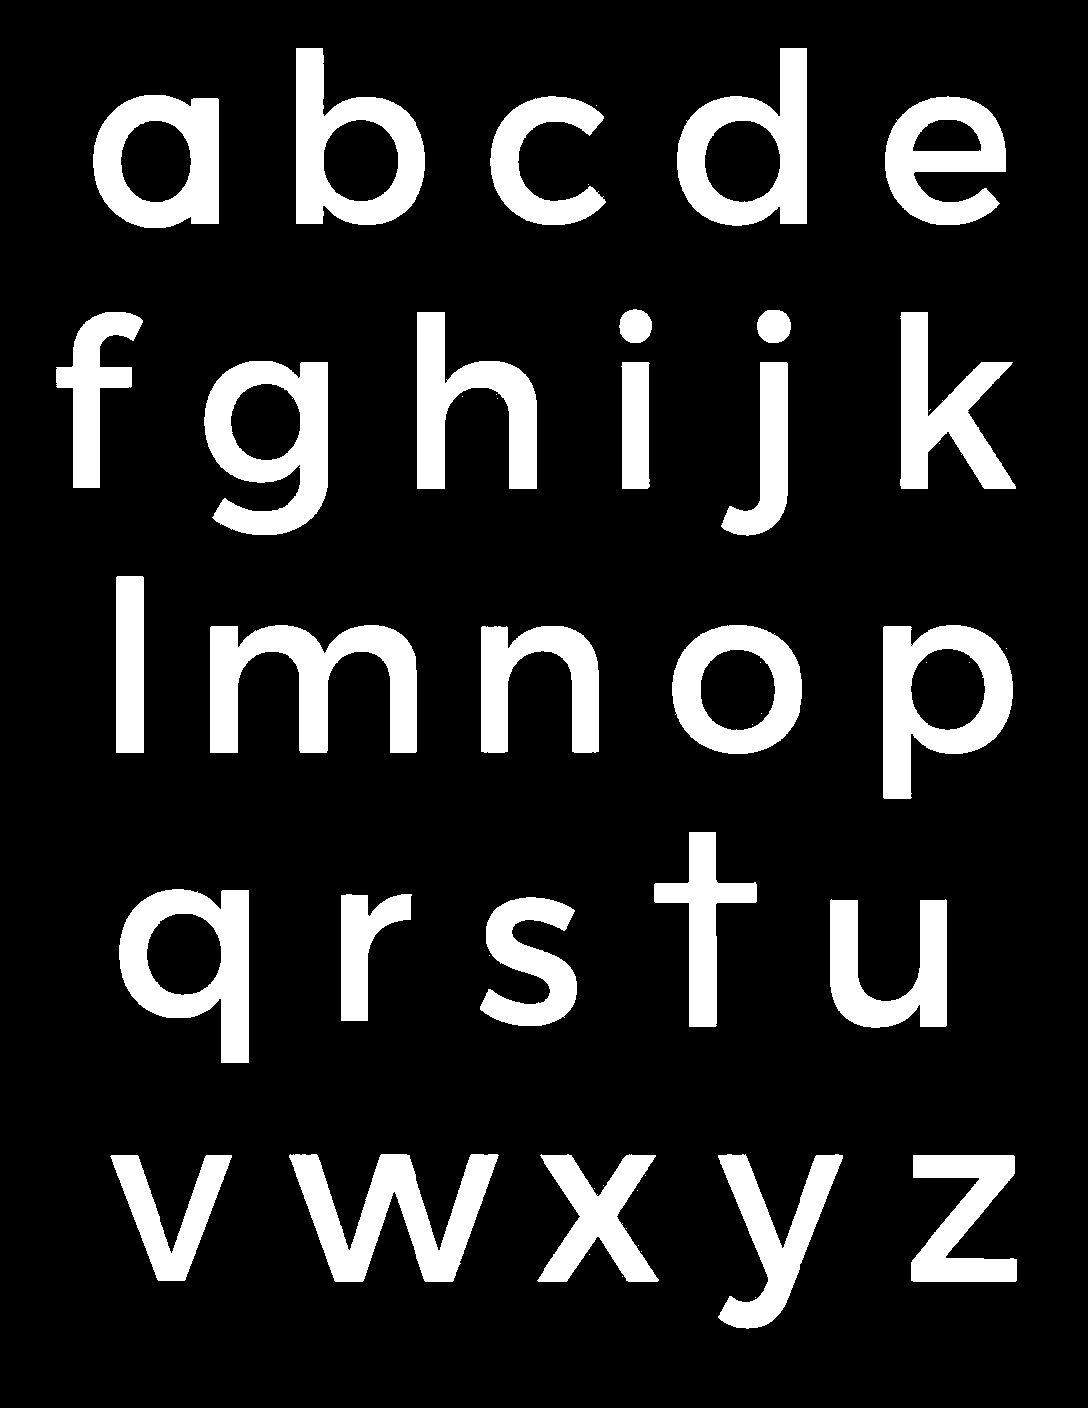

(1, 1)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 29ms/step
(1, 1)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 59ms/step
(1, 1)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 31ms/step
(1, 1)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 37ms/step
(1, 1)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 65ms/step
(1, 1)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 83ms/step
(1, 1)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 47ms/step
(1, 1)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 17ms/step
(1, 1)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 15ms/step
(1, 1)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 19ms/step
(127, 106)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 16ms/step
(126, 122)
(28, 28)
(1, 28, 28)
1/1 [==============================] - 0s 16ms/step
(175, 125)
(28, 28)
(1, 28, 28)


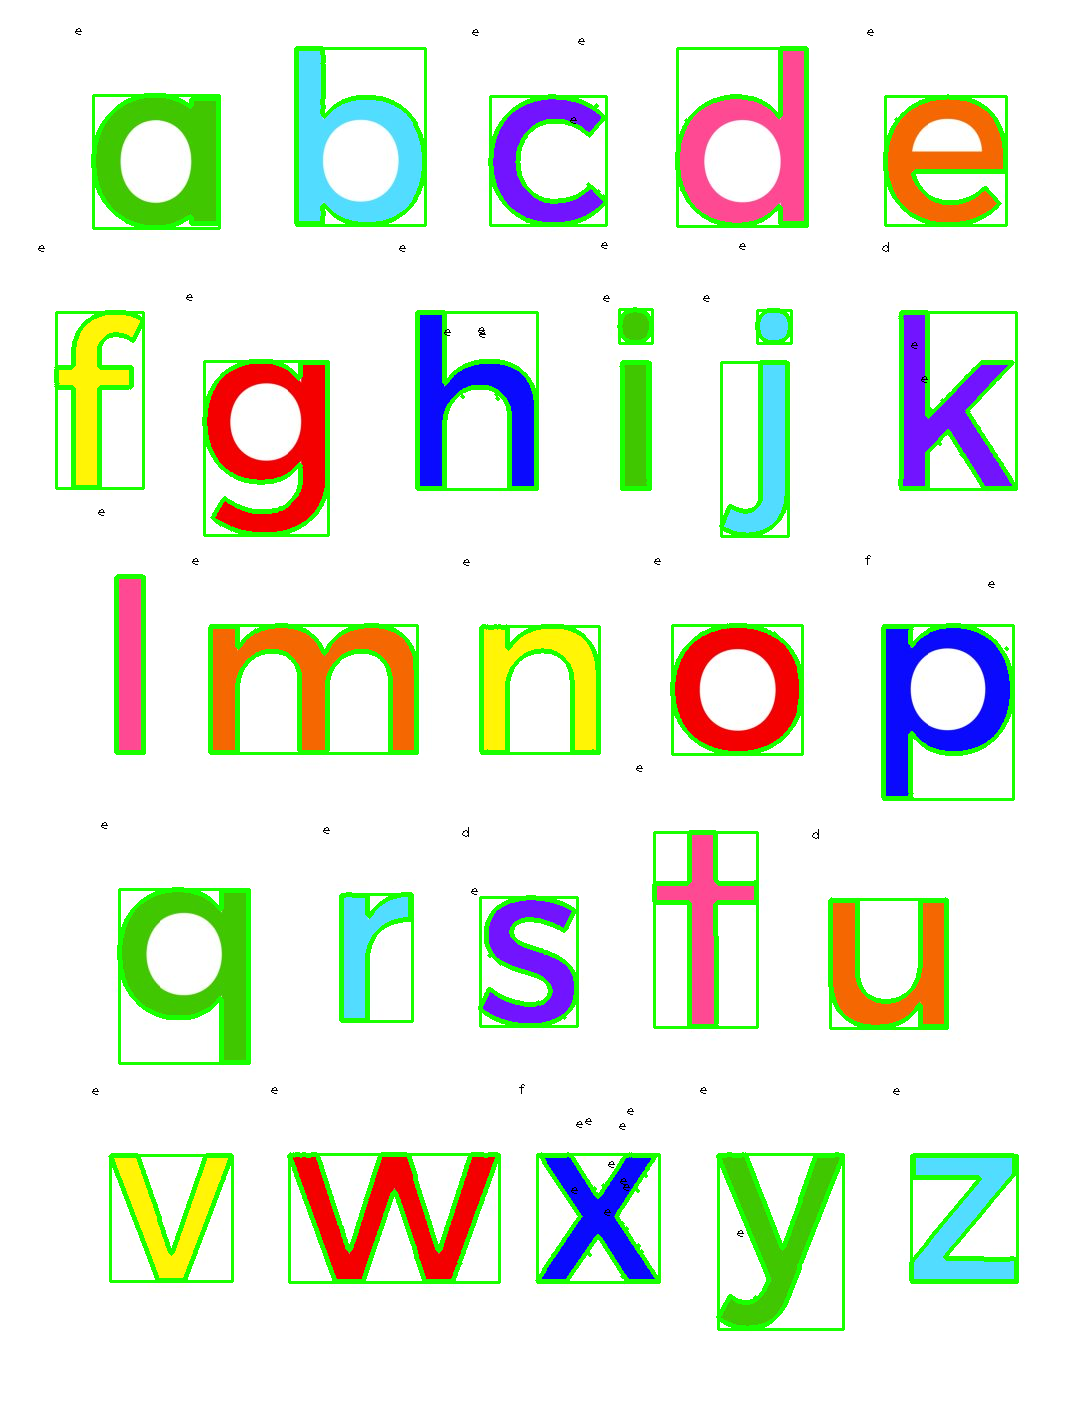

In [ ]:
import cv2
from keras.models import load_model
from google.colab.patches import cv2_imshow


# model = load_model('/content/emnist_cnn.h5')

# cap = cv2.VideoCapture(0)
frame = cv2.imread('/content/images.jpg')
# while True:
    # _, frame = cap.read()
# print(frame.shape)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
var, threshold_img = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
cv2_imshow(threshold_img)
ctrs, _ = cv2.findContours(threshold_img.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# print(len(ctrs))
cv2.drawContours(frame, ctrs, -1, (0, 255, 25), 3)
# print(len(ctrs))
for contour in ctrs:
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 25), 2)
    img = threshold_img[y:y+h, x:x+w]
    print(img.shape)
    img = cv2.resize(img, (28, 28), frame, interpolation = cv2.INTER_AREA)
    # img = tf.keras.utils.img_to_array(img)
    # img.resize((28, 28, 1))
    print(img.shape)
    # img = img/255

    img = np.expand_dims(img, axis = 0)
    print(img.shape)
    predictions = model.predict([img])
    # print(predictions)
    cv2.putText(frame, str(class_names[np.argmax(predictions)-1]), (x-20, y-60), cv2.FONT_HERSHEY_PLAIN, 1, (0, 0, 0), 1)

cv2_imshow(frame)

if cv2.waitKey(10) == ord('q'):
    exit()

# cv2.release()]
cv2.waitKey()
cv2.destroyAllWindows()


